Tutorial original en ultralytics

https://colab.research.google.com/github/ultralytics/ultralytics/blob/main/examples/tutorial.ipynb#scrollTo=bpF9-vS_DAaf

Copia de trabajo de `13 YOLO ultralytics.ipynb` para el ejercicio 1 de
Vision computacional: correr tal cual, y luego sustituir la imagen de
prediccion por una propia (misma imagen en ambas celdas de prediccion).

In [1]:
%pip install -q ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.150  Python-3.11.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060, 8187MiB)


Setup complete  (12 CPUs, 31.8 GB RAM, 709.6/930.5 GB disk)


In [2]:
# Helper para mostrar la ultima prediccion (imagen con cajas) dentro de la
# notebook, asi el .ipynb exportado queda completo sin depender de abrir
# runs/detect/ a mano.
from pathlib import Path
from IPython.display import Image, display

def show_last_prediction(filename):
    candidates = sorted(Path('runs/detect').glob('predict*'), key=lambda p: p.stat().st_mtime)
    latest = candidates[-1]
    display(Image(filename=str(latest / filename)))


# 1. Predict (original)

Corrida sin cambios: zidane.jpg y bus.jpg, tal como viene la notebook.

In [3]:
# Run inference on an image with YOLOv8n
!yolo predict model=yolov8n.pt source='https://ultralytics.com/images/zidane.jpg'

Ultralytics 8.4.150  Python-3.11.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060, 8187MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

Found https://ultralytics.com/images/zidane.jpg locally at zidane.jpg
image 1/1 C:\Users\PC PRIDE OSTRICH PRO\AppData\Local\Temp\claude\c--Users-PC-PRIDE-OSTRICH-PRO-Documentos-GitHub-inteligencia-artificial\263c3ca3-55f3-4026-beb5-4091d5743f61\scratchpad\yolo\zidane.jpg: 384x640 2 persons, 1 tie, 9.5ms
Speed: 41.9ms preprocess, 9.5ms inference, 10.8ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\Users\PC PRIDE OSTRICH PRO\AppData\Local\Temp\claude\c--Users-PC-PRIDE-OSTRICH-PRO-Documentos-GitHub-inteligencia-artificial\263c3ca3-55f3-4026-beb5-4091d5743f61\scratchpad\yolo\runs\detect\predict-7
 Learn more at https://docs.ultralytics.com/modes/predict


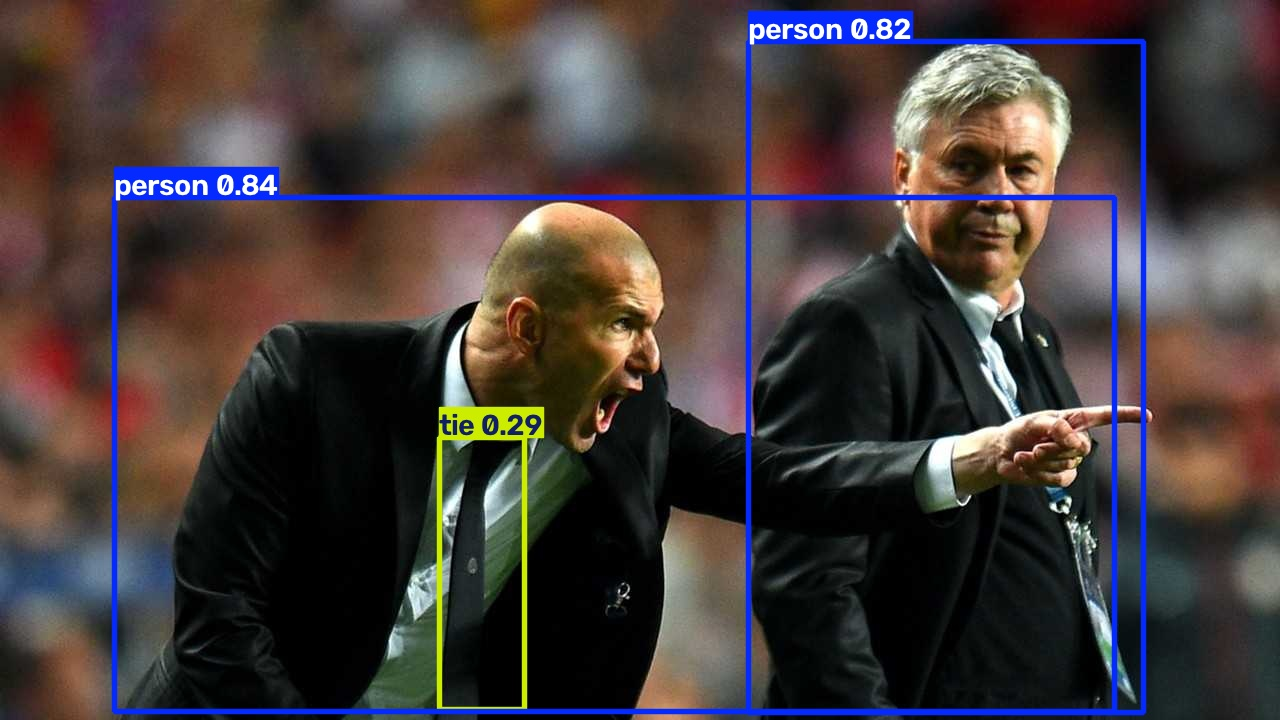

In [4]:
show_last_prediction('zidane.jpg')

## 1. Detection (entrenamiento + prediccion original sobre bus.jpg)

In [5]:
# Load YOLOv8n, train it on COCO128 for 3 epochs and predict an image with it
from ultralytics import YOLO

model = YOLO('yolov8n.pt')  # load a pretrained YOLOv8n detection model
model.train(data='coco128.yaml', epochs=3)  # train the model
model('https://ultralytics.com/images/bus.jpg', save=True)  # predict on an image

Ultralytics 8.4.150  Python-3.11.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060, 8187MiB)


engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=None, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretr


                   from  n    params  module                                       arguments                     


  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 


  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                


...

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg


image 1/1 C:\Users\PC PRIDE OSTRICH PRO\AppData\Local\Temp\claude\c--Users-PC-PRIDE-OSTRICH-PRO-Documentos-GitHub-inteligencia-artificial\263c3ca3-55f3-4026-beb5-4091d5743f61\scratchpad\yolo\bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 12.1ms


Speed: 1.5ms preprocess, 12.1ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 480)


Results saved to C:\Users\PC PRIDE OSTRICH PRO\AppData\Local\Temp\claude\c--Users-PC-PRIDE-OSTRICH-PRO-Documentos-GitHub-inteligencia-artificial\263c3ca3-55f3-4026-beb5-4091d5743f61\scratchpad\yolo\runs\detect\predict-8


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 

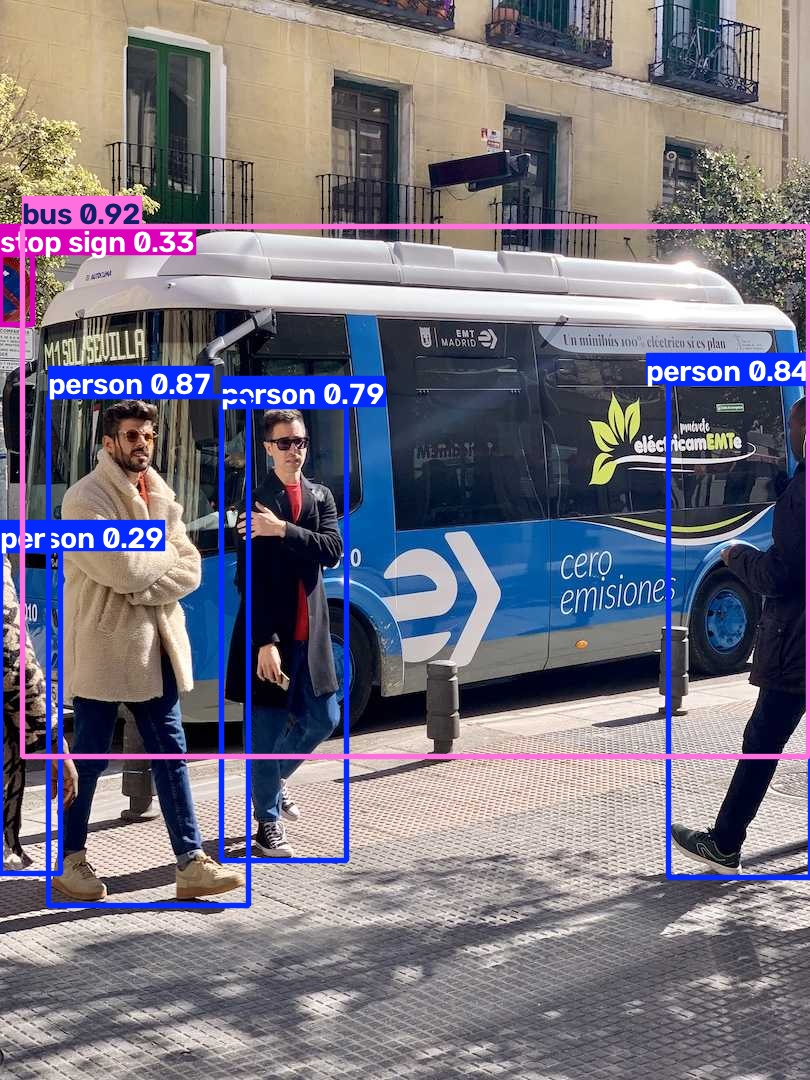

In [6]:
show_last_prediction('bus.jpg')

## 2. Predict sobre mi propia imagen

Unico cambio de codigo: la fuente de la imagen en las dos celdas de
prediccion (CLI y Python). El modelo sigue siendo `yolov8n.pt`.

In [7]:
!yolo predict model=yolov8n.pt source='mi_foto.jpg'

Ultralytics 8.4.150  Python-3.11.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060, 8187MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

image 1/1 C:\Users\PC PRIDE OSTRICH PRO\AppData\Local\Temp\claude\c--Users-PC-PRIDE-OSTRICH-PRO-Documentos-GitHub-inteligencia-artificial\263c3ca3-55f3-4026-beb5-4091d5743f61\scratchpad\yolo\mi_foto.jpg: 640x640 2 persons, 9.8ms
Speed: 45.5ms preprocess, 9.8ms inference, 9.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\PC PRIDE OSTRICH PRO\AppData\Local\Temp\claude\c--Users-PC-PRIDE-OSTRICH-PRO-Documentos-GitHub-inteligencia-artificial\263c3ca3-55f3-4026-beb5-4091d5743f61\scratchpad\yolo\runs\detect\predict-9
 Learn more at https://docs.ultralytics.com/modes/predict


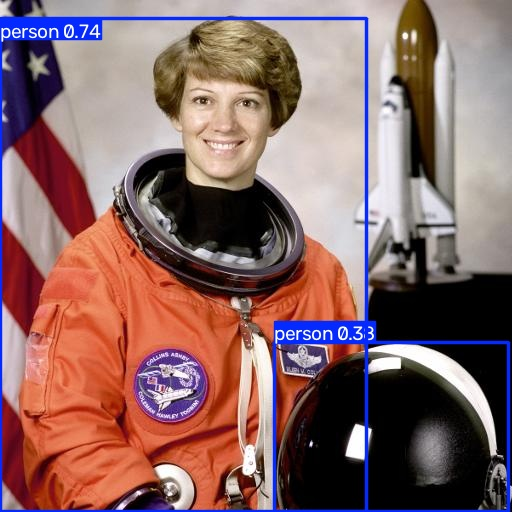

In [8]:
show_last_prediction('mi_foto.jpg')

In [9]:
model2 = YOLO('yolov8n.pt')
result = model2('mi_foto.jpg', save=True)
print(result[0].verbose())

image 1/1 C:\Users\PC PRIDE OSTRICH PRO\AppData\Local\Temp\claude\c--Users-PC-PRIDE-OSTRICH-PRO-Documentos-GitHub-inteligencia-artificial\263c3ca3-55f3-4026-beb5-4091d5743f61\scratchpad\yolo\mi_foto.jpg: 640x640 2 persons, 8.3ms


Speed: 1.7ms preprocess, 8.3ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


Results saved to C:\Users\PC PRIDE OSTRICH PRO\AppData\Local\Temp\claude\c--Users-PC-PRIDE-OSTRICH-PRO-Documentos-GitHub-inteligencia-artificial\263c3ca3-55f3-4026-beb5-4091d5743f61\scratchpad\yolo\runs\detect\predict-10


2 persons, 


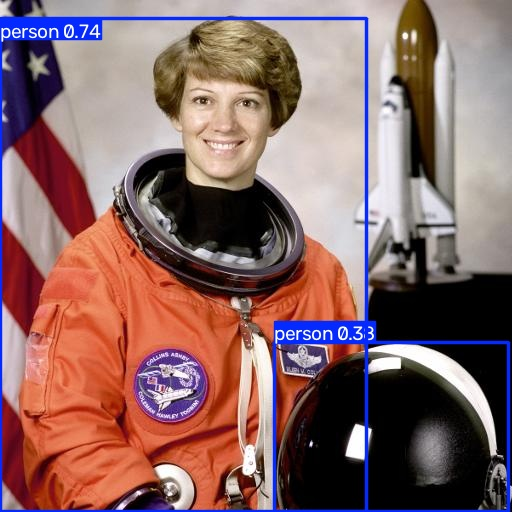

In [10]:
show_last_prediction('mi_foto.jpg')

## Reto opcional

### a) Umbral mas estricto (conf=0.7) sobre mi imagen

In [11]:
!yolo predict model=yolov8n.pt source='mi_foto.jpg' conf=0.7

Ultralytics 8.4.150  Python-3.11.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060, 8187MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

image 1/1 C:\Users\PC PRIDE OSTRICH PRO\AppData\Local\Temp\claude\c--Users-PC-PRIDE-OSTRICH-PRO-Documentos-GitHub-inteligencia-artificial\263c3ca3-55f3-4026-beb5-4091d5743f61\scratchpad\yolo\mi_foto.jpg: 640x640 1 person, 9.2ms
Speed: 42.6ms preprocess, 9.2ms inference, 9.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\PC PRIDE OSTRICH PRO\AppData\Local\Temp\claude\c--Users-PC-PRIDE-OSTRICH-PRO-Documentos-GitHub-inteligencia-artificial\263c3ca3-55f3-4026-beb5-4091d5743f61\scratchpad\yolo\runs\detect\predict-11
 Learn more at https://docs.ultralytics.com/modes/predict


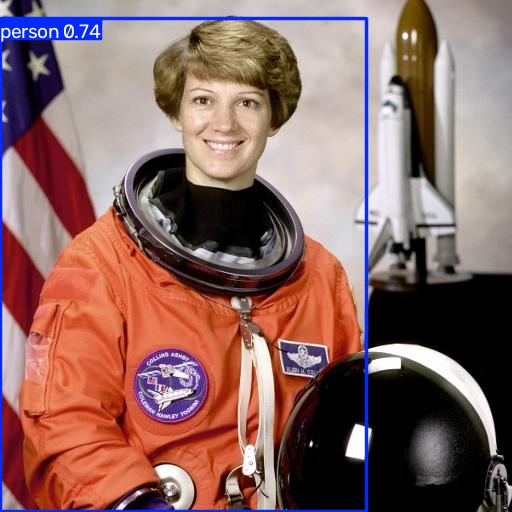

In [12]:
show_last_prediction('mi_foto.jpg')

### b) Mismo modelo mas grande (yolov8s.pt), sin reentrenar

In [13]:
!yolo predict model=yolov8s.pt source='mi_foto.jpg'

Ultralytics 8.4.150  Python-3.11.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060, 8187MiB)
YOLOv8s summary (fused): 72 layers, 11,156,544 parameters, 0 gradients, 28.6 GFLOPs

image 1/1 C:\Users\PC PRIDE OSTRICH PRO\AppData\Local\Temp\claude\c--Users-PC-PRIDE-OSTRICH-PRO-Documentos-GitHub-inteligencia-artificial\263c3ca3-55f3-4026-beb5-4091d5743f61\scratchpad\yolo\mi_foto.jpg: 640x640 3 persons, 1 traffic light, 8.8ms
Speed: 47.9ms preprocess, 8.8ms inference, 9.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\PC PRIDE OSTRICH PRO\AppData\Local\Temp\claude\c--Users-PC-PRIDE-OSTRICH-PRO-Documentos-GitHub-inteligencia-artificial\263c3ca3-55f3-4026-beb5-4091d5743f61\scratchpad\yolo\runs\detect\predict-12
 Learn more at https://docs.ultralytics.com/modes/predict


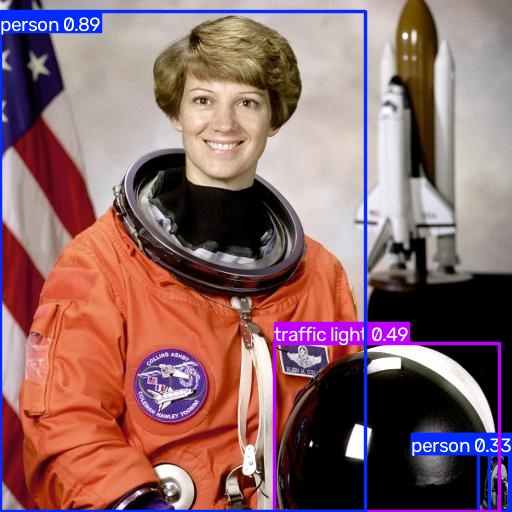

In [14]:
show_last_prediction('mi_foto.jpg')